<a href="https://colab.research.google.com/github/alitorbzadeh/CodeBySematec/blob/main/model_augmented.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install patool

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.4/101.4 kB 3.2 MB/s eta 0:00:00


In [ ]:
import patoolib
patoolib.extract_archive("/content/drive/MyDrive/Augmented_DataSet2.rar",outdir='/content/sample_data')

INFO patool: Extracting /content/drive/MyDrive/Augmented_DataSet2.rar ...
INFO patool: running /usr/bin/unrar x -kb -or -- /content/drive/MyDrive/Augmented_DataSet2.rar
INFO patool: ... /content/drive/MyDrive/Augmented_DataSet2.rar extracted to `/content/sample_data'.


'/content/sample_data'

In [ ]:
# List of Libraries

import os
import warnings

warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ["TF_ENABLE_ONEDNN_OTPS"] = "0"

import glob
import numpy as np
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.layers import Dropout, BatchNormalization, Activation
from keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [ ]:
# # Preparation of Dataset

# all_images = []
# labels = []
# for image_path in glob.glob('/content/sample_data/Augmented_DataSet2/*/*'):
#   img = cv2.imread(image_path)
#   img = cv2.resize(img,(64,64))
#   img = img / 255.0
#   all_images.append(img)
#   labels.append(image_path.split('/')[-2])
# all_images = np.array(all_images)
# lb = LabelBinarizer()
# labels = lb.fit_transform(labels)
# x_train, x_test, y_train, y_test = train_test_split(all_images, labels, test_size=0.2, random_state=42)

# print(f'x_train Size: {x_train.shape}')
# print(f'x_test Size: {x_test.shape}')
# print(f'y_train Size: {y_train.shape}')
# print(f'y_test Size: {y_test.shape}')

x_train Size: (26400, 64, 64, 3)
x_test Size: (6600, 64, 64, 3)
y_train Size: (26400, 11)
y_test Size: (6600, 11)


In [ ]:
data_dir = '/content/sample_data/Augmented_DataSet2'

data_generetor = ImageDataGenerator(rescale=1./255,validation_split=0.2)

train_generator = data_generetor.flow_from_directory(
    data_dir,
    target_size=(64, 64),
    batch_size=64,
    class_mode='categorical',
    subset='training'
)

val_generator = data_generetor.flow_from_directory(
    data_dir,
    target_size=(64, 64),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

Found 26400 images belonging to 11 classes.
Found 6600 images belonging to 11 classes.


In [ ]:
model = Sequential([

    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3),padding = 'same'),
    Conv2D(32, (3, 3), activation='relu',padding='same'),
    Conv2D(32, (3, 3), activation='relu',padding='same'),
    Dropout(0.3),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu',padding='same'),
    Conv2D(64, (3, 3), activation='relu',padding='same'),
    Dropout(0.3),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu',padding='same'),
    # Conv2D(128, (3, 3), padding='same', activation= 'relu'),
    Dropout(0.3),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    # BatchNormalization(),
    Dropout(0.3),
    Dense(11, activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'], )
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,198,795 (4.57 MB)

 Trainable params: 1,198,795 (4.57 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(train_generator, epochs=35, validation_data=val_generator)

Epoch 1/35
 10/413 ━━━━━━━━━━━━━━━━━━━━ 19:53 3s/step - accuracy: 0.0732 - loss: 2.4118

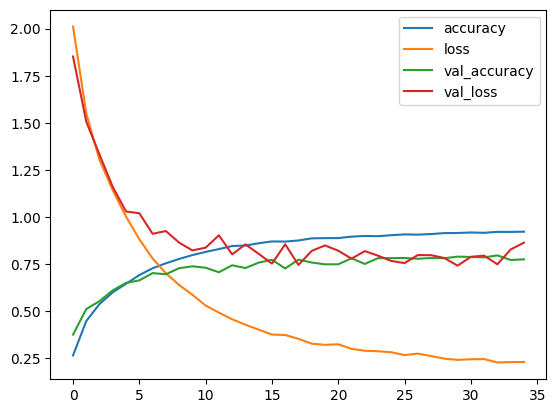

In [ ]:
pd.DataFrame(history.history).plot()
plt.show()